In [1447]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [1448]:
nr_of_seeds = 30 #nr of seeds in the experiments

In [1449]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [1450]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_32176\100240269.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_32176\100240269.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_32176\100240269.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

<Axes: xlabel='method', ylabel='rmse'>

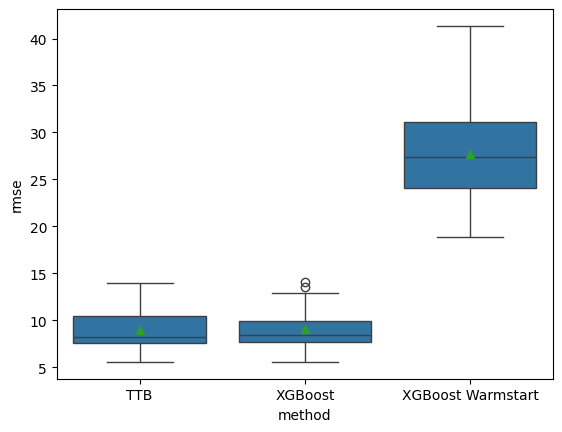

In [1451]:
sub_name = 'volume_150'

dat = pd.read_csv(f'results_{sub_name}/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results_{sub_name}/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'

# data = pd.read_csv(f'results/xgb_naive.csv')
# naive_xgboost_data = data
# naive_xgboost_data['method'] = 'Naïve XGBoost'

# best_naive_XGBoost, lk = topk_per_d_per_method(
#     naive_xgboost_data,
# ['v', 'target_tree_size'], k=nr_of_seeds
# )
# best_naive_XGBoost['method'] = 'Naïve XGBoost'

data = pd.read_csv(f'results_{sub_name}/xgb_warmstart.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart ['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart , best_XGBoost_params_warmstart  = topk_per_d_per_method(
    xgboost_data_warmstart ,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_warmstart ['method'] = 'XGBoost Warmstart'



df = best_LSTransferTreeBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
df = pd.concat([df, best_XGBoost_warmstart])
#df = pd.concat([df, best_naive_XGBoost])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [1452]:
#Obtain best parameters in order based on test rmse
dat = pd.read_csv(f'results_{sub_name}/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=100000
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results_{sub_name}/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=100000
)
best_XGBoost['method'] = 'XGBoost'

data = pd.read_csv(f'results_{sub_name}/xgb_warmstart.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart ['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart , best_XGBoost_params_warmstart  = topk_per_d_per_method(
    xgboost_data_warmstart ,
['v', 'target_tree_size'], k=100000
)
best_XGBoost_warmstart ['method'] = 'XGBoost Warmstart'

# data = pd.read_csv(f'results/two_trada_{index}.csv')
# trada_data = data
# trada_data['method'] = 'two-stage TrAdaBoost.R2'

# best_trada, jk = topk_per_d_per_method(
#     trada_data,
# ['method'], k=nr_of_seeds
# )
# best_trada['method'] = 'two-stage TrAdaBoost.R2'

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_32176\3404690135.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_32176\3404690135.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_32176\3404690135.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

In [1453]:
#Get best params in order
best_LSTransferTreeBoost_params.iloc[::nr_of_seeds]

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,avg_mae,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
873,0.1,1.0,3.0,0.00,0.5,8.939756,6.294776,30,872.0,400.0,7.613913,5.741412,5.561874,3.891637,TransferTreeBoost
419,0.1,1.0,3.0,0.01,0.5,8.947338,6.184611,30,865.0,400.0,7.898301,6.440496,7.657091,5.226727,TransferTreeBoost
1943,0.1,3.0,3.0,0.00,0.1,8.978792,6.199091,30,886.0,400.0,8.169778,5.941145,7.757525,5.468304,TransferTreeBoost
412,0.1,2.0,3.0,0.01,0.5,9.011806,6.245025,30,865.0,400.0,7.837741,6.487154,7.731630,5.425037,TransferTreeBoost
1551,0.1,1.0,3.0,0.05,0.9,9.040577,6.207724,30,881.0,400.0,9.303634,6.749016,5.806602,4.811154,TransferTreeBoost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,0.1,3.0,3.0,0.01,0.9,10.736977,7.735718,30,884.0,400.0,12.835715,10.429785,16.928063,14.121636,TransferTreeBoost
1960,0.1,2.0,2.0,0.01,0.9,10.843798,7.997177,30,887.0,400.0,9.089155,6.481944,8.876706,6.609823,TransferTreeBoost
980,0.1,2.0,3.0,0.01,0.9,10.938336,8.070655,30,873.0,400.0,15.199026,11.276458,12.926528,10.246620,TransferTreeBoost
1283,0.1,3.0,2.0,0.01,0.9,11.280302,8.338744,30,877.0,400.0,9.345470,6.362184,9.663565,7.420239,TransferTreeBoost


In [1454]:
#Get best params in order
best_XGBoost_params.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
633,0.15,3.0,9.112798,6.327868,30,626,877.0,8.527508,5.628043,9.769412,7.425402,XGBoost
911,0.10,3.0,9.129643,6.398537,30,908,885.0,14.321700,7.745975,10.185514,7.540969,XGBoost
528,0.20,3.0,9.150744,6.389052,30,524,874.0,13.267285,7.517888,8.421795,5.767287,XGBoost
10,0.20,4.0,9.163706,6.377339,30,21,860.0,5.324167,4.116571,6.390332,4.721235,XGBoost
2,0.05,3.0,9.181888,6.441820,30,2,860.0,5.697437,4.309688,6.584971,4.757180,XGBoost
350,0.25,3.0,9.185615,6.394884,30,350,869.0,11.541272,7.048340,8.330365,5.706735,XGBoost
741,0.30,4.0,9.196111,6.349520,30,753,880.0,9.634162,6.991177,12.996433,8.034495,XGBoost
746,0.10,4.0,9.209244,6.424145,30,729,880.0,8.786097,6.458415,13.120071,8.077803,XGBoost
52,0.30,3.0,9.234137,6.409936,30,68,861.0,6.964601,5.101924,13.741158,7.350772,XGBoost
632,0.15,4.0,9.244099,6.444006,30,627,877.0,8.799815,5.670844,9.778519,7.525012,XGBoost


In [1455]:
#Get best params in order
best_XGBoost_params_warmstart.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
1,0.05,2.0,27.738537,19.617704,30,1,860.0,32.835576,18.929318,33.311882,19.685254,XGBoost Warmstart
1027,0.10,2.0,28.453105,20.188391,30,1015,888.0,17.655128,13.086577,29.783280,21.044087,XGBoost Warmstart
88,0.05,1.0,28.996613,20.762417,30,72,862.0,23.949848,19.824206,32.932382,25.790912,XGBoost Warmstart
338,0.05,3.0,29.085822,20.988039,30,326,869.0,35.129001,25.435379,18.129013,13.684427,XGBoost Warmstart
121,0.15,2.0,29.773849,20.968340,30,121,863.0,27.335113,18.921972,26.959596,20.137208,XGBoost Warmstart
342,0.10,1.0,30.152240,21.696875,30,330,869.0,33.602207,24.678538,20.021472,14.493557,XGBoost Warmstart
823,0.15,1.0,31.452921,22.714520,30,804,882.0,24.783469,18.274460,36.264368,25.364578,XGBoost Warmstart
56,0.10,3.0,31.550004,22.566977,30,44,861.0,25.226870,17.545809,30.071395,25.757922,XGBoost Warmstart
288,0.20,2.0,31.572544,22.418907,30,307,868.0,40.291749,27.424789,31.459519,23.187315,XGBoost Warmstart
718,0.15,3.0,31.715643,22.719484,30,698,879.0,37.972046,23.171363,36.149716,25.837531,XGBoost Warmstart


In [1456]:
((best_XGBoost_params.iloc[0]['avg_rmse'] - best_LSTransferTreeBoost_params.iloc[0]['avg_rmse']) / best_XGBoost_params.iloc[0]['avg_rmse'])*100

np.float64(1.8988875063882427)

In [1457]:
import numpy as np
np.std(best_XGBoost_params.iloc[:30]['rmse'])

np.float64(2.203763702436141)